In [1]:
# Import the libraries we need for sentiment analysis
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the cleaned reviews we saved in Task 1
df = pd.read_csv('../data/raw/reviews.csv')

# Quick check
print(f"Total reviews loaded: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst review:")
print(df['review'][0])

Total reviews loaded: 1478
Columns: ['review', 'rating', 'date', 'bank', 'source']

First review:
🤙🏼🤙🏼


In [4]:
# Create the sentiment analyzer (our "judge")
analyzer = SentimentIntensityAnalyzer()

# Empty lists to store results
sentiment_labels = []
sentiment_scores = []

# Loop through every review and analyze it
for review in df['review']:
    # Get the sentiment scores
    scores = analyzer.polarity_scores(str(review))
    
    # The compound score is between -1 and 1
    compound = scores['compound']
    
    # Decide the label based on the compound score
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    
    sentiment_labels.append(label)
    sentiment_scores.append(compound)

# Add results to our dataframe
df['sentiment_label'] = sentiment_labels
df['sentiment_score'] = sentiment_scores

print("Sentiment analysis complete!")
print(f"\nSentiment distribution:")
print(df['sentiment_label'].value_counts())

Sentiment analysis complete!

Sentiment distribution:
sentiment_label
positive    904
neutral     365
negative    209
Name: count, dtype: int64


<Figure size 1000x600 with 0 Axes>

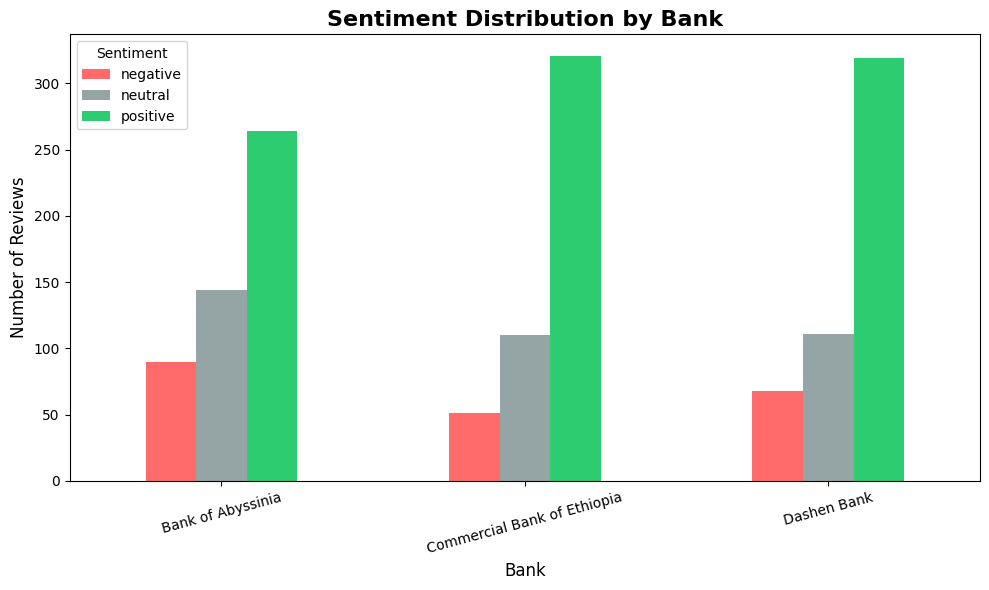

In [6]:
# Create a bar chart showing sentiment distribution per bank
plt.figure(figsize=(10, 6))

# Count sentiment labels per bank
sentiment_by_bank = df.groupby(['bank', 'sentiment_label']).size().unstack()

# Plot
sentiment_by_bank.plot(
    kind='bar',
    color=['#ff6b6b', '#95a5a6', '#2ecc71'],
    figsize=(10, 6)
)

plt.title('Sentiment Distribution by Bank', fontsize=16, fontweight='bold')
plt.xlabel('Bank', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Sentiment')
plt.tight_layout()

# Save the chart
plt.savefig('../data/raw/sentiment_chart.png', dpi=150)
plt.show()



In [7]:
# Save the reviews with sentiment labels to a new CSV
df.to_csv('../data/raw/reviews_with_sentiment.csv', index=False)

print("Saved reviews with sentiment labels!")
print(f"Total reviews: {len(df)}")
print(f"\nSentiment breakdown per bank:")
print(df.groupby(['bank', 'sentiment_label']).size().unstack())

Saved reviews with sentiment labels!
Total reviews: 1478

Sentiment breakdown per bank:
sentiment_label              negative  neutral  positive
bank                                                    
Bank of Abyssinia                  90      144       264
Commercial Bank of Ethiopia        51      110       321
Dashen Bank                        68      111       319
